In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [10]:
DATASET_PATH =r"C:\Users\Admin\Desktop\Project 2\oral_disease_raw_dataset"

In [11]:
class_counts = {}

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        image_count = len(os.listdir(class_path))
        class_counts[class_name] = image_count

print("Class Distribution:")
print(class_counts)

Class Distribution:
{'Calculus': 234, 'Caries': 219, 'Hypodontia': 276, 'Mouth Ulcers': 265, 'Tooth Discoloration': 182}


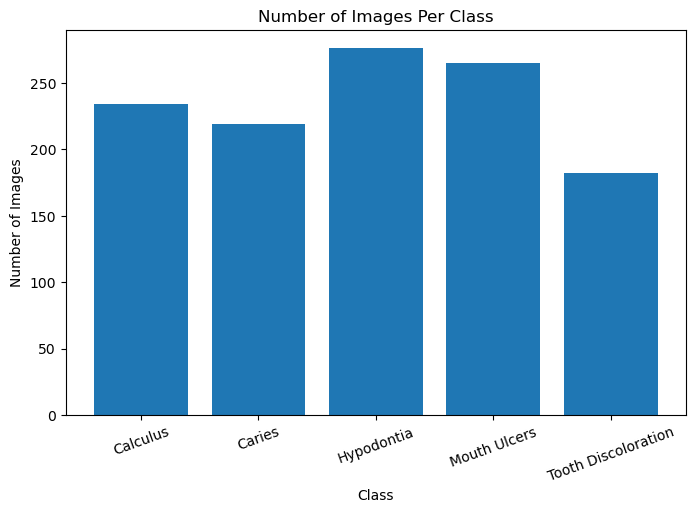

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images Per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

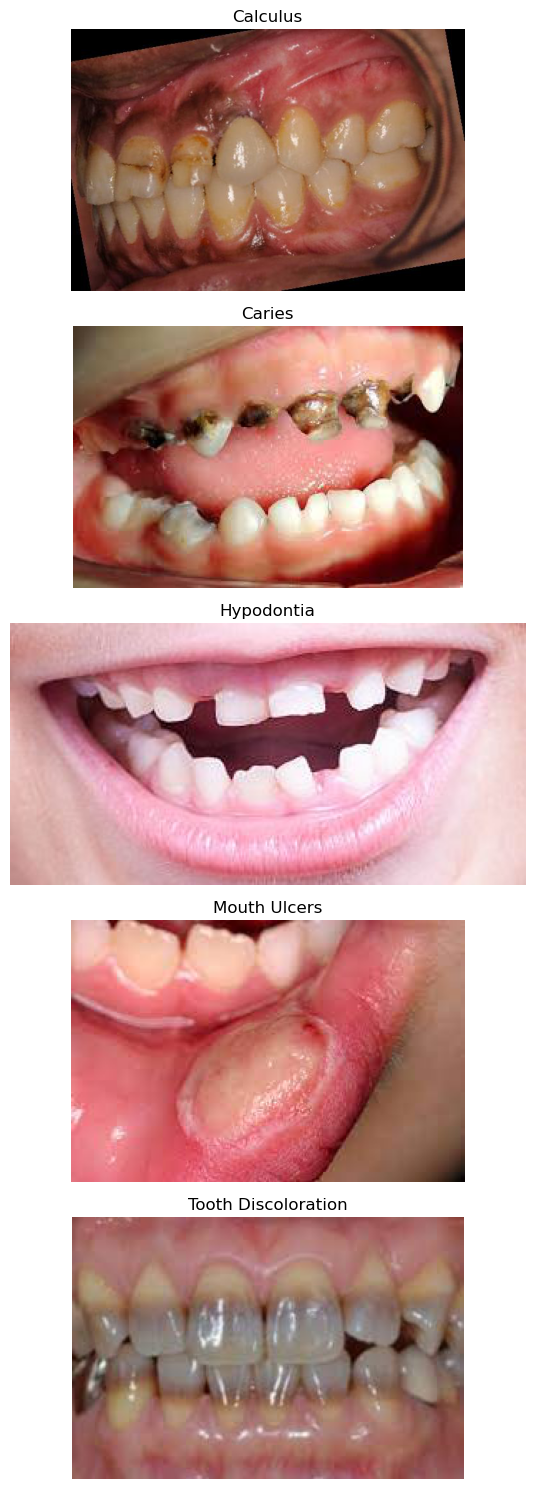

In [16]:
fig, axes = plt.subplots(len(class_counts), 1, figsize=(6, 15))

for row, class_name in enumerate(class_counts.keys()):
    class_path = os.path.join(DATASET_PATH, class_name)

    # Take only one image from each class
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    axes[row].imshow(image)
    axes[row].set_title(class_name)
    axes[row].axis("off")

plt.tight_layout()
plt.show()


In [17]:
image_sizes = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)
        except:
            pass

print("Sample Image Sizes:")
print(image_sizes[:10])

Sample Image Sizes:
[(612, 407), (612, 407), (612, 405), (612, 407), (612, 407), (612, 408), (612, 406), (612, 293), (612, 408), (612, 408)]


In [18]:
unique_sizes = list(set(image_sizes))

print("Unique Image Sizes:")
print(unique_sizes)
print("Total Unique Sizes:", len(unique_sizes))

Unique Image Sizes:
[(612, 612), (123, 91), (612, 194), (322, 157), (225, 151), (315, 160), (612, 395), (612, 340), (612, 459), (601, 612), (418, 121), (240, 160), (612, 477), (418, 194), (605, 612), (326, 154), (384, 171), (200, 252), (201, 251), (168, 299), (276, 183), (612, 452), (612, 397), (259, 194), (612, 406), (280, 180), (268, 178), (311, 158), (280, 363), (266, 190), (272, 185), (252, 200), (257, 196), (612, 125), (177, 121), (258, 195), (612, 363), (612, 308), (525, 612), (247, 204), (612, 372), (459, 612), (612, 317), (306, 198), (393, 258), (408, 612), (284, 177), (173, 291), (278, 182), (279, 181), (612, 390), (270, 187), (299, 168), (612, 335), (213, 199), (612, 399), (612, 518), (307, 453), (612, 463), (262, 192), (260, 103), (291, 173), (365, 177), (251, 201), (246, 205), (290, 174), (245, 206), (175, 117), (269, 188), (220, 149), (298, 169), (612, 420), (612, 246), (260, 194), (464, 293), (289, 175), (612, 255), (215, 235), (612, 319), (612, 438), (612, 264), (376, 13

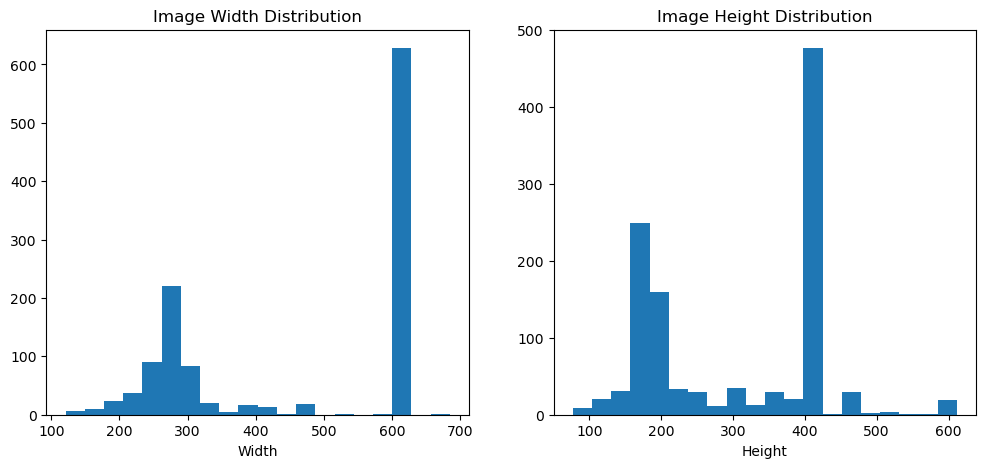

In [19]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")

plt.show()

In [20]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [22]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [25]:
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

In [27]:
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler

In [28]:
train_labels = [train_dataset.dataset.samples[i][1] for i in train_dataset.indices]

class_sample_count = np.array([
    train_labels.count(i) for i in range(len(class_names))
])

print("Training Class Counts:", class_sample_count)

weights = 1.0 / class_sample_count

sample_weights = [weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Training Class Counts: [168 160 190 187 118]


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)



Using Device: cpu


In [48]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [49]:

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, n_classes)

model = model.to(device)

In [50]:
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

In [51]:
# ============================================================
# EARLY STOPPING SETTINGS
# ============================================================

best_val_loss = float('inf')
patience = 5
counter = 0

# ============================================================
# TRAINING LOOP WITH EARLY STOPPING
# ============================================================

for epoch in range(EPOCHS):

    # ---------------- TRAINING ----------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.2f}%")
    print("-" * 50)

    # ============================================================
    # EARLY STOPPING
    # ============================================================

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_resnet50_dental_model.pth")
        print("Validation loss improved. Model saved.")

    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s)")

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/25]
Train Loss: 1.1727 | Train Accuracy: 60.87%
Val Loss: 0.7656 | Val Accuracy: 77.84%
--------------------------------------------------
Validation loss improved. Model saved.
Epoch [2/25]
Train Loss: 0.4623 | Train Accuracy: 87.61%
Val Loss: 0.4076 | Val Accuracy: 89.77%
--------------------------------------------------
Validation loss improved. Model saved.
Epoch [3/25]
Train Loss: 0.2186 | Train Accuracy: 95.02%
Val Loss: 0.3958 | Val Accuracy: 88.07%
--------------------------------------------------
Validation loss improved. Model saved.
Epoch [4/25]
Train Loss: 0.1077 | Train Accuracy: 97.21%
Val Loss: 0.3569 | Val Accuracy: 90.91%
--------------------------------------------------
Validation loss improved. Model saved.
Epoch [5/25]
Train Loss: 0.0996 | Train Accuracy: 97.08%
Val Loss: 0.4457 | Val Accuracy: 89.77%
--------------------------------------------------
No improvement for 1 epoch(s)
Epoch [6/25]
Train Loss: 0.0641 | Train Accuracy: 97.69%
Val Loss: 0.4011 

In [52]:
model.load_state_dict(torch.load("best_resnet50_dental_model.pth"))
model.eval()

print("Best model loaded successfully")


Best model loaded successfully


In [53]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [54]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9040
Precision : 0.9088
Recall    : 0.9040
F1 Score  : 0.9036


In [55]:
print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


Classification Report:

                     precision    recall  f1-score   support

           Calculus       0.80      0.93      0.86        30
             Caries       0.88      0.74      0.81        31
         Hypodontia       0.96      1.00      0.98        47
       Mouth Ulcers       1.00      0.91      0.95        43
Tooth Discoloration       0.82      0.88      0.85        26

           accuracy                           0.90       177
          macro avg       0.89      0.89      0.89       177
       weighted avg       0.91      0.90      0.90       177



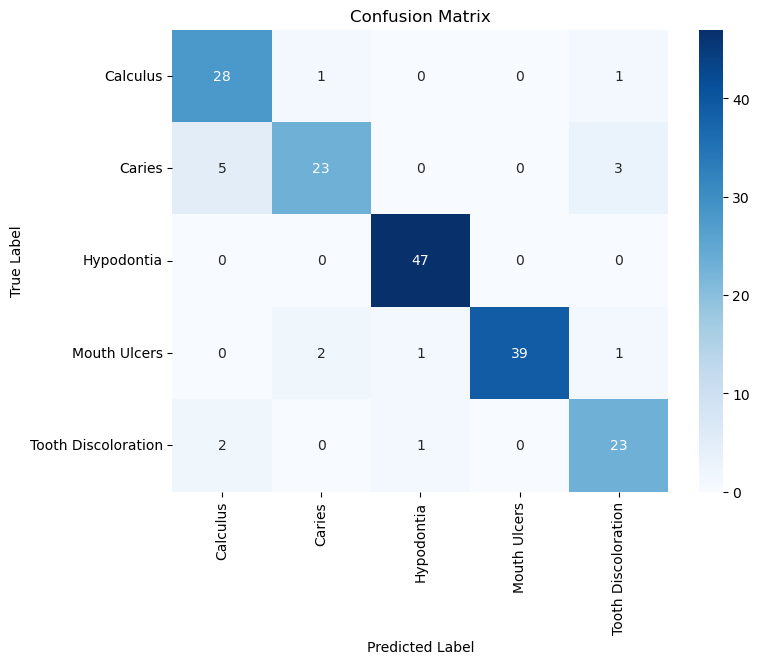

In [56]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [57]:
torch.save(model.state_dict(), "final_resnet50_dental_model.pth")

print("Final model saved successfully")

Final model saved successfully


In [58]:
treatment_recommendations = {
    "Calculus": "Professional dental cleaning and scaling is recommended.",
    "Caries": "Dental filling or root canal treatment may be needed depending on severity.",
    "Hypodontia": "Orthodontic treatment, dental implants, or bridges may be recommended.",
    "Mouth Ulcers": "Topical gels, mouth rinses, hydration, and avoiding spicy foods may help.",
    "Tooth Discoloration": "Professional whitening, veneers, or polishing may be recommended."
}

In [59]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    predicted_class = class_names[predicted.item()]
    recommendation = treatment_recommendations[predicted_class]

    print("Predicted Disease:", predicted_class)
    print("Treatment Recommendation:", recommendation)


In [ ]:
test_image_path = r"C:\Users\Admin\Desktop\Project 2\test_ulcer.png"

predict_image(test_image_path)

Predicted Disease: Mouth Ulcers
Treatment Recommendation: Topical gels, mouth rinses, hydration, and avoiding spicy foods may help.


In [62]:
target_layer = model.layer4[-1]

In [63]:
pip install grad-cam

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [65]:
def show_gradcam(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    rgb_img = np.array(image).astype(np.float32) / 255.0

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    predicted_class_idx = predicted.item()
    predicted_class = class_names[predicted_class_idx]
    confidence_score = confidence.item() * 100

    print("Predicted Disease:", predicted_class)
    print(f"Confidence Score: {confidence_score:.2f}%")

    # Grad-CAM
    target_layer = model.layer4[-1]

    cam = GradCAM(
        model=model,
        target_layers=[target_layer]
    )

    targets = [ClassifierOutputTarget(predicted_class_idx)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0, :]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM: {predicted_class}")
    plt.axis("off")

    plt.show()

Predicted Disease: Tooth Discoloration
Confidence Score: 99.84%


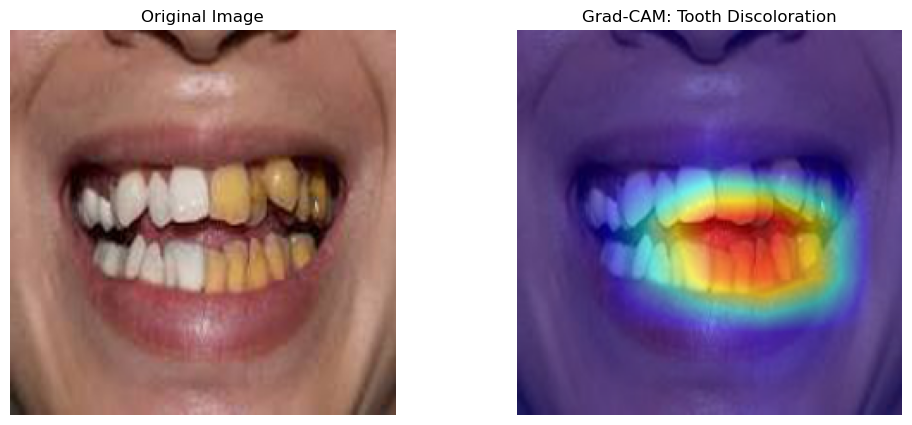

In [66]:
show_gradcam(r"C:\Users\Admin\Desktop\Project 2\test_image.jfif")

Predicted Disease: Mouth Ulcers
Confidence Score: 77.65%


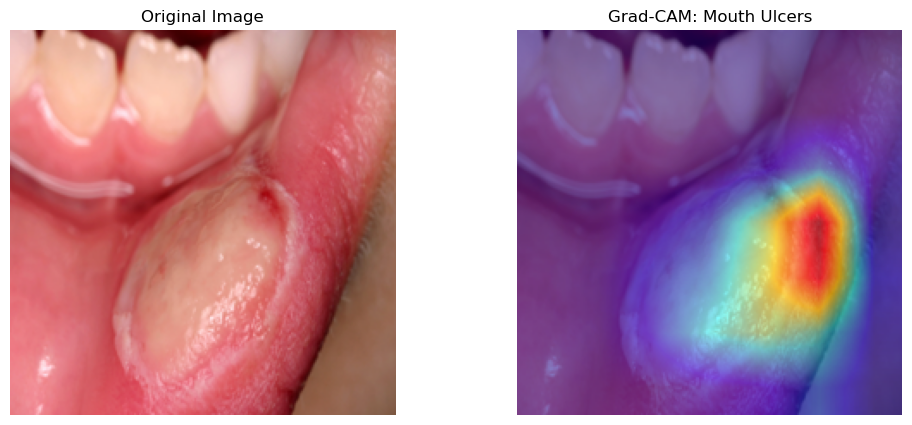

In [73]:
show_gradcam(r"C:\Users\Admin\Desktop\Project 2\test_ulcer.png")